In [3]:
# Import all the packages and function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings
warnings.simplefilter("ignore", ConvergenceWarning)

# Special helper function for the Holiday Boost
from helper_functions import (
    is_christmas,
    is_mothers_day,
    is_special_day,
    mothers_day,
    is_silvester,
    holiday_average_last_3_years
)

# Load dataset
df = pd.read_csv("../data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])

# Drop columns to prevent data leakage
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

df = df.sort_values("Datum").set_index("Datum")

# Define target variable
target_col = "Tagesumsatz Restaurant"

# Define MAPE function for evalutation
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

SARIMAX Model 
(with integrated Hyperparametertuning)

NaNs in ts: 0
NaNs in exog: weekday                                                  0
is_fr_sa                                                 0
Ferien-Value                                             0
Special-Day-Value                                        0
Niederschlag Tagessumme 6 UTC                            0
Sonnenscheindauer Tagessumme                             0
Lufttemperatur 2m Tagesmittel                            0
Durchschnittliche Anzahl Geburtstage (über 100 Jahre)    0
fourier_sin_1                                            0
fourier_cos_1                                            0
fourier_sin_2                                            0
fourier_cos_2                                            0
fourier_sin_3                                            0
fourier_cos_3                                            0
fourier_sin_4                                            0
fourier_cos_4                                            0
fourier_sin_5               

c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the 

Trying order=(1, 0, 1), seasonal=(1, 0, 1, 7)


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been prov

Trying order=(1, 0, 1), seasonal=(2, 1, 1, 7)


...

Trying order=(2, 1, 2), seasonal=(2, 1, 1, 7)


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


        order seasonal_order       MAPE           AIC
1   (1, 0, 1)   (1, 0, 1, 7)  19.060168  26188.140859
4   (2, 0, 2)   (1, 0, 1, 7)  19.520375  26196.094850
2   (1, 0, 1)   (2, 1, 1, 7)  25.882997  26193.755573
5   (2, 0, 2)   (2, 1, 1, 7)  26.141438  26185.504581
10  (2, 1, 2)   (1, 0, 1, 7)  26.430156  26219.094003

Best model: (1, 0, 1) (1, 0, 1, 7)


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the 


Final Metrics
MSE : 8719336.16157576
RMSE: 2952.852207878979
R2  : 0.7653612735929616
MAE : 2281.200529618345
MAPE: 19.01095267255229
Relative MSE: 0.263064939893062


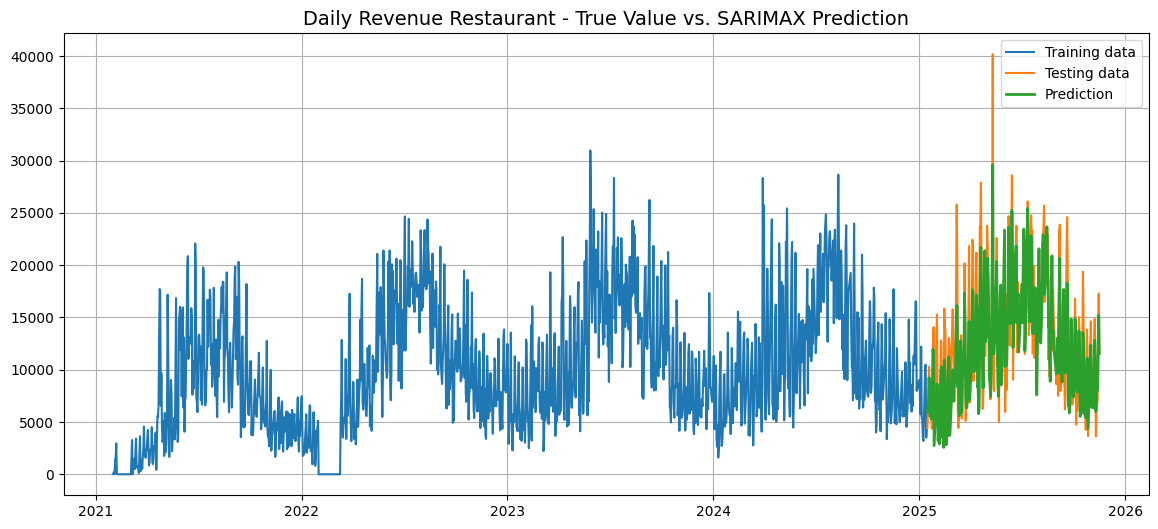

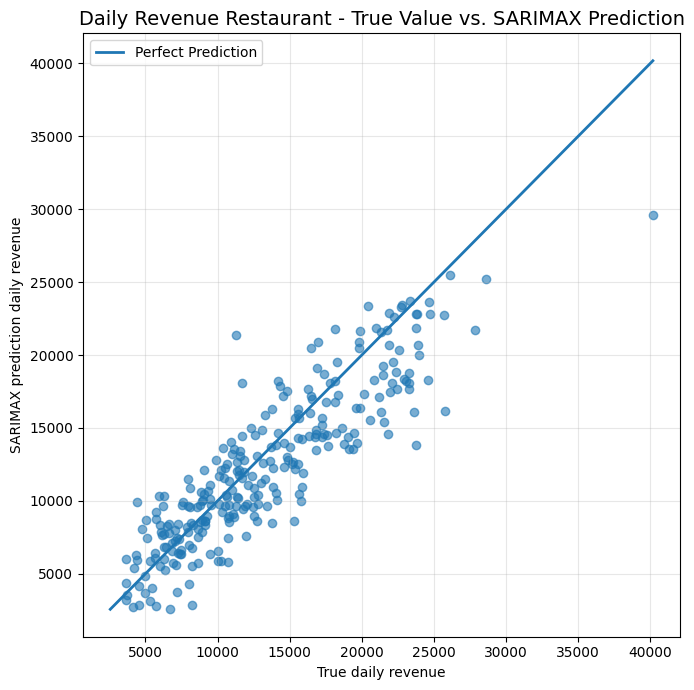

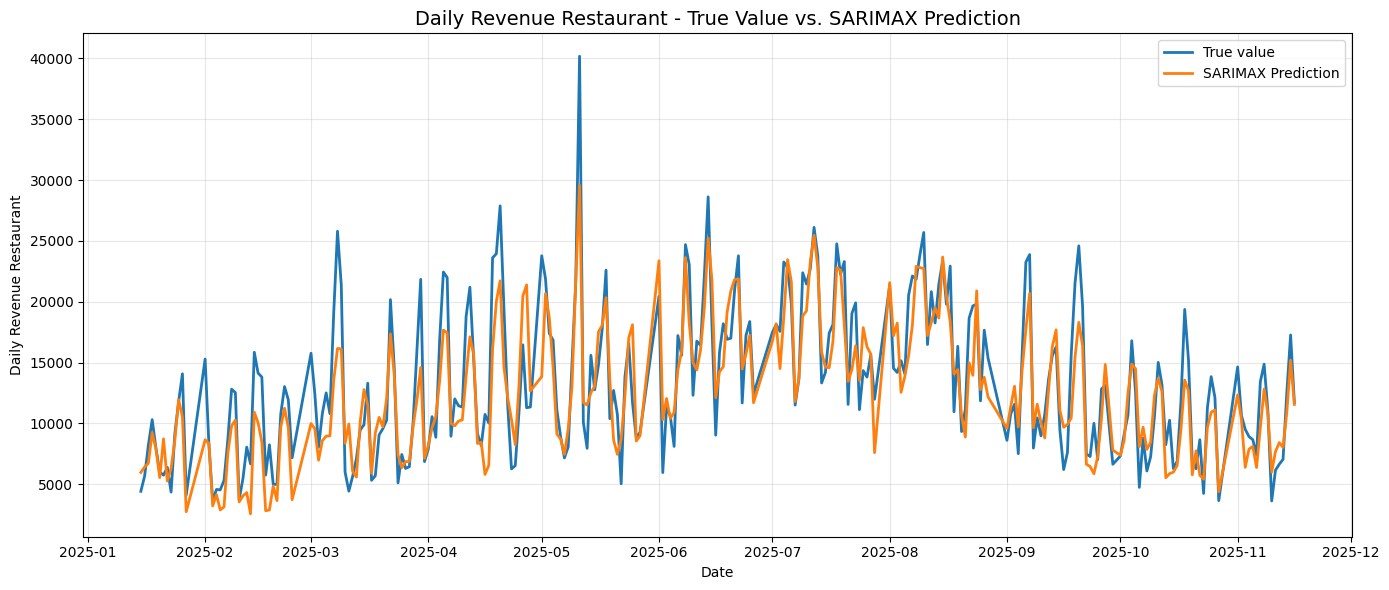

In [4]:

# Prepare time series and make sure frequency is daily
ts = df[target_col].asfreq("D")
ts = pd.to_numeric(ts, errors="coerce")
ts = ts.ffill().bfill()


# Create all the features
# Create a dataframe with Date as index
exog = pd.DataFrame(index=df.index)

# Map the weekdays
if "Tag" in df.columns:
    mapping = {"Mo": 0, "Di": 1, "Mi": 2, "Do": 3, "Fr": 4, "Sa": 5, "So": 6}
    exog["weekday"] = df["Tag"].map(mapping)
else:
    exog["weekday"] = df.index.weekday

# Weekend Bonus for Friday, Saturday and Sunday
if "is_fr_sa" in df.columns:
    exog["is_fr_sa"] = df["is_fr_sa"]
else:
    exog["is_fr_sa"] = ((df.index.weekday >= 5) | (df.index.weekday == 4)).astype(int)

# Other features
feature_cols = [
    "Ferien-Value",
    "Special-Day-Value",
    "Niederschlag Tagessumme 6 UTC",
    "Sonnenscheindauer Tagessumme",
    "Lufttemperatur 2m Tagesmittel",
    "Durchschnittliche Anzahl Geburtstage (über 100 Jahre)"
]

for col in feature_cols:
    if col in df.columns:
        exog[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        exog[col] = 0.0

# Add the Fourier Features
# We generate Fourier series features (sine & cosine waves) that represent
# smooth yearly seasonality and adds them as exogenous regressors
def make_fourier_features(index, period=365.25, K=7): #7 is only a default number, will be overwritten later
    df_fourier = pd.DataFrame(index=index) # create empty DataFrame
    t = index.dayofyear.values.astype(float) #This gives the index values between 1-365 to tell the model where we are in the annual cycle

    for k in range(1, K+1):
        df_fourier[f"fourier_sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        df_fourier[f"fourier_cos_{k}"] = np.cos(2 * np.pi * k * t / period)

    return df_fourier

fourier_df = make_fourier_features(exog.index, K=16) # this is the real K we use
exog = pd.concat([exog, fourier_df], axis=1)


# Build in lag features
exog["lag1"]  = ts.shift(1)
exog["lag2"]  = ts.shift(2)
exog["lag3"]  = ts.shift(3)
exog["lag7"]  = ts.shift(7)
exog["lag14"] = ts.shift(14)
exog["lag21"] = ts.shift(21)
exog["lag28"] = ts.shift(28)
exog["lag30"] = ts.shift(30)
combined = pd.concat([ts, exog], axis=1).dropna()
ts   = combined[target_col]
exog = combined.drop(columns=[target_col])


# Make sure exog is a smooth time series DataFrame
exog = exog.asfreq("D")
exog = exog.replace([np.inf, -np.inf], np.nan)
exog = exog.ffill().bfill()

print("NaNs in ts:", ts.isna().sum())
print("NaNs in exog:", exog.isna().sum())


#Train/Test-Split
split_date = pd.Timestamp("2025-01-15")
train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

exog_train = exog.loc[train.index]
exog_test  = exog.loc[test.index]

print("Train length (inkl. Spezialtage):", len(train))


# Remove the special days (Christmas, New Year, Mothersday from the exog_train data)
train_dates = train.index
special_mask = pd.Series(train_dates).apply(is_special_day).values

train = train[~special_mask]
exog_train = exog_train[~special_mask]

print("Train length (ohne Spezialtage):", len(train))
print("Test length:", len(test))


# Setup Grid Search (automatic Hyperparametertuning)
candidate_orders = [(1,0,1), (2,0,2), (1,1,1), (2,1,2)]
candidate_seasonal_orders = [(1,1,1,7), (1,0,1,7), (2,1,1,7)]
results = []

for order in candidate_orders:
    for seasonal_order in candidate_seasonal_orders:
        try:
            print(f"Trying order={order}, seasonal={seasonal_order}")

            model = SARIMAX(
                train,
                exog=exog_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=True, #AR parameters are restricted to a stable region
                enforce_invertibility=True #The optimizer is prevented from choosing MA parameters that lead to non-invertible (unstable) behavior
            )
     
            fit = model.fit(disp=False)

            tmp_forecast = fit.get_forecast(steps=len(test), exog=exog_test).predicted_mean

            mse_tmp = mean_squared_error(test, tmp_forecast)
            mape_tmp = mape(test, tmp_forecast)

            results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "MAPE": mape_tmp,
                "AIC": fit.aic
            })

        except Exception as e:
            print("Error:", e)

results_df = pd.DataFrame(results).sort_values("MAPE")
print(results_df.head())

best = results_df.iloc[0]
best_order = tuple(best["order"])
best_seasonal = tuple(best["seasonal_order"])

print("\nBest model:", best_order, best_seasonal)


# Create the final Model (the same as just before)
final_model = SARIMAX(
    train,
    exog=exog_train,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=True,
    enforce_invertibility=True
)
final_fit = final_model.fit(disp=False)

forecast_raw = final_fit.get_forecast(steps=len(test), exog=exog_test).predicted_mean


# Prediction plus Holiday boost
forecast_adjusted = forecast_raw.values.copy()
test_dates = test.index

df_full = df.copy()
if "Datum" not in df_full.columns:
    df_full = df_full.reset_index().rename(columns={"index": "Datum"})

for i, d in enumerate(test_dates):
    d_ts = pd.Timestamp(d)
    year = d_ts.year

    # Christmas
    if is_christmas(d_ts):
        avg_xmas = holiday_average_last_3_years(df_full, lambda y: pd.Timestamp(y,12,24), year, target_col)
        if avg_xmas is not None:
            forecast_adjusted[i] = avg_xmas

    # New Year's Eve
    if is_silvester(d_ts):
        avg_silvester = holiday_average_last_3_years(df_full, lambda y: pd.Timestamp(y,12,31), year, target_col)
        if avg_silvester is not None:
            forecast_adjusted[i] = avg_silvester

    # Mothersday
    if is_mothers_day(d_ts):
        avg_mothers = holiday_average_last_3_years(df_full, mothers_day, year, target_col)
        if avg_mothers is not None:
            forecast_adjusted[i] = avg_mothers

forecast_adjusted = pd.Series(forecast_adjusted, index=test.index)


# Evaluation metrics
mse  = mean_squared_error(test, forecast_adjusted)
rmse = np.sqrt(mse)
r2   = r2_score(test, forecast_adjusted)
mae  = mean_absolute_error(test, forecast_adjusted)
mape_val = mape(test, forecast_adjusted)

y_naive = test.shift(1).bfill()
mse_naive = mean_squared_error(test, y_naive)
rel_mse = mse / mse_naive

print("\nFinal Metrics")
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)
print("MAE :", mae)
print("MAPE:", mape_val)
print("Relative MSE:", rel_mse)


# Plots
# Time series plot: True vs. Prediction
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Training data")
plt.plot(test.index, test, label="Testing data")
plt.plot(test.index, forecast_adjusted, label="Prediction", linewidth=2)
plt.title("Daily Revenue Restaurant - True Value vs. SARIMAX Prediction", fontsize=14)
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(7, 7))

plt.scatter(test.values, forecast_adjusted.values, alpha=0.6)

# Scatter-Plot: True vs. Predicted
min_val = min(test.min(), forecast_adjusted.min())
max_val = max(test.max(), forecast_adjusted.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfect Prediction")

plt.title("Daily Revenue Restaurant - True Value vs. SARIMAX Prediction", fontsize=14)
plt.xlabel("True daily revenue")
plt.ylabel("SARIMAX prediction daily revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Time series plot: True vs. Prediction (compact)
plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label="True value", linewidth=2)
plt.plot(test.index, forecast_adjusted, 
         label="SARIMAX Prediction", linewidth=2)

plt.title("Daily Revenue Restaurant - True Value vs. SARIMAX Prediction", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Daily Revenue Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
# Daily Absolute Percentage Error (APE) in the test period
eps = (test - forecast_adjusted)
ape = (eps.abs() / test.replace(0, np.nan)) * 100  # in %


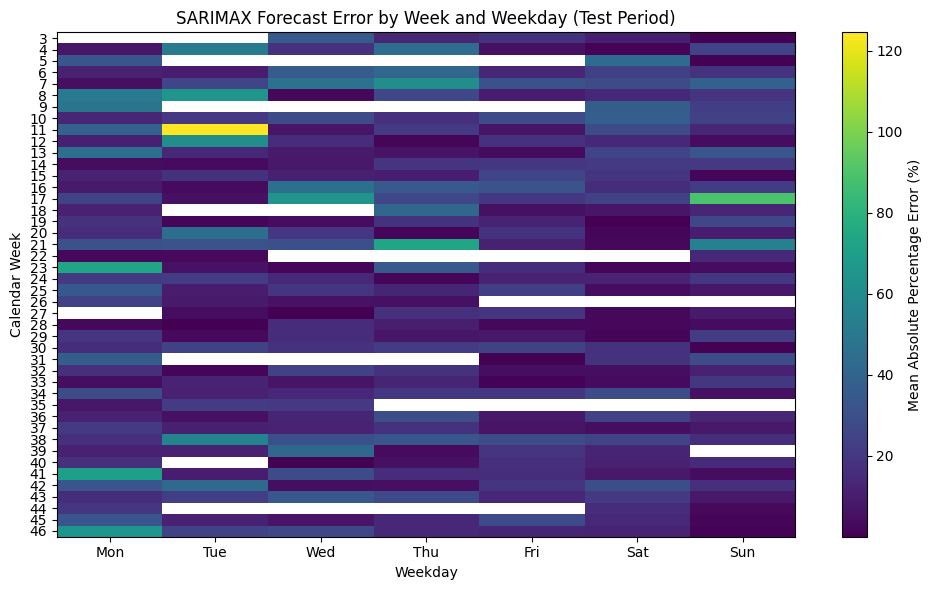

In [8]:
import matplotlib.pyplot as plt

# Build a small DataFrame with date info and error
err_df = ape.to_frame(name="APE")
err_df["weekday"] = err_df.index.weekday           # 0=Mon ... 6=Sun
err_df["week"]    = err_df.index.isocalendar().week

# Average APE by week & weekday
pivot = err_df.pivot_table(index="week", columns="weekday", values="APE", aggfunc="mean")

# Order columns Monday..Sunday
pivot = pivot[[0,1,2,3,4,5,6]]
pivot.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(10, 6))
im = plt.imshow(pivot.values, aspect="auto")

# Tick labels
plt.xticks(range(7), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.title("SARIMAX Forecast Error by Week and Weekday (Test Period)")
plt.xlabel("Weekday")
plt.ylabel("Calendar Week")

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label("Mean Absolute Percentage Error (%)")

plt.tight_layout()
plt.show()


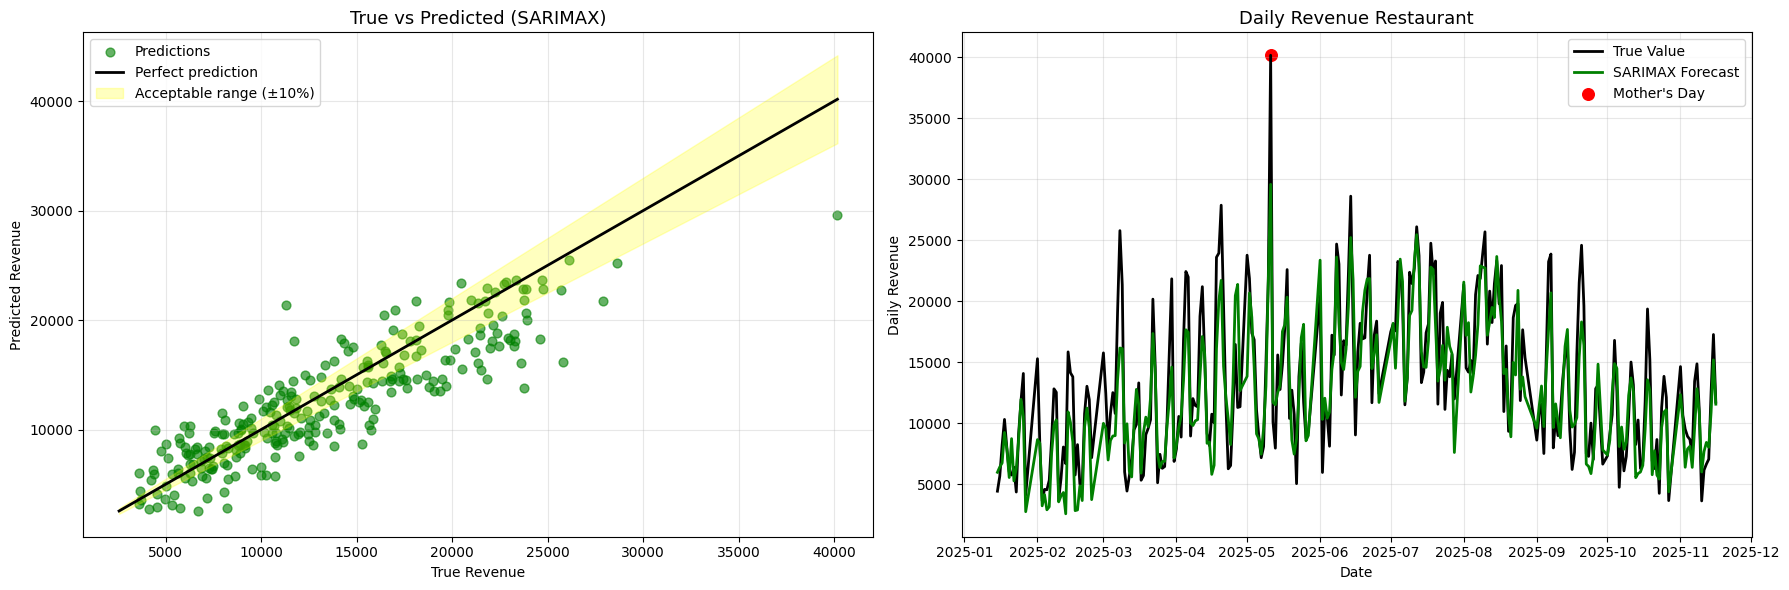

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare diagonal for scatter
min_val = min(test.min(), forecast_adjusted.min())
max_val = max(test.max(), forecast_adjusted.max())

# Define acceptable error band (e.g. +/- 10%)
tol = 0.20   # 10% tolerance

true_vals = np.linspace(min_val, max_val, 500)
upper_band = true_vals * (1 + tol)
lower_band = true_vals * (1 - tol)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ============================================================
# 1) LEFT PLOT – Scatter: True vs Predicted + Tolerance Band
# ============================================================
ax1 = axes[0]

# Scatter points
ax1.scatter(test.values,
            forecast_adjusted.values,
            alpha=0.6, s=40, color="green", label="Predictions")

# Perfect prediction line
ax1.plot(true_vals, true_vals,
         linewidth=2, color="black", label="Perfect prediction")

# Tolerance band (shaded area)
ax1.fill_between(true_vals, lower_band, upper_band,
                 color="yellow", alpha=0.25,
                 label=f"Acceptable range (±{int(tol*100)}%)")

ax1.set_title("True vs Predicted (SARIMAX)", fontsize=13)
ax1.set_xlabel("True Revenue")
ax1.set_ylabel("Predicted Revenue")
ax1.grid(True, alpha=0.3)
ax1.legend()

# ============================================================
# 2) RIGHT PLOT – Line chart (test period only)
# ============================================================
ax2 = axes[1]

# True series
ax2.plot(test.index, test.values,
         label="True Value",
         linewidth=2, color="black")

# SARIMAX Forecast
ax2.plot(test.index, forecast_adjusted.values,
         label="SARIMAX Forecast",
         linewidth=2, color="green")

# Special day markers
is_mothers = np.array([is_mothers_day(d) for d in test.index])

ax2.scatter(test.index[is_mothers],
            test.values[is_mothers],
            color="red", s=70, label="Mother's Day")

ax2.set_title("Daily Revenue Restaurant", fontsize=13)
ax2.set_xlabel("Date")
ax2.set_ylabel("Daily Revenue")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()
